In [204]:
## Importar paquetes
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error as mse

In [205]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [206]:
data = pd.read_csv("/content/dielectron.csv")
#1) Run: The run number of the event.
#2) Event: The event number.
#3, 11) E1, E2: The total energy of the electron (GeV) for electrons 1 and 2.
#4, 5, 6, 12, 13, 14) px1,py1,pz1,px2,py2,pz2: The components of the momemtum of the electron 1 and 2 (GeV).
#7, 15) pt1, pt2: The transverse momentum of the electron 1 and 2 (GeV).
#8, 16) eta1, eta2: The pseudorapidity of the electron 1 and 2.
#9, 17) phi1, phi2: The phi angle of the electron 1 and 2 (rad).
#10, 18) Q1, Q2: The charge of the electron 1 and 2.
#19) M: The invariant mass of two electrons (GeV).

##PREDECIR LA INVARIANZA DE LA MASA DE DOS ELECTRONES


In [207]:
data

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.71410,-7.311320,10.531000,-57.29740,12.82020,-2.202670,2.177660,1,11.28360,-1.032340,-1.88066,-11.077800,2.14537,-2.344030,-2.072810,-1,8.94841
1,147115,366704169,6.61188,-4.152130,-0.579855,-5.11278,4.19242,-1.028420,-3.002840,-1,17.14920,-11.713500,5.04474,11.464700,12.75360,0.808077,2.734920,1,15.89300
2,147115,367112316,25.54190,-11.480900,2.041680,22.72460,11.66100,1.420480,2.965600,1,15.82030,-1.472800,2.25895,-15.588800,2.69667,-2.455080,2.148570,1,38.38770
3,147115,366952149,65.39590,7.512140,11.887100,63.86620,14.06190,2.218380,1.007210,1,25.12730,4.087860,2.59641,24.656300,4.84272,2.330210,0.565865,-1,3.72862
4,147115,366523212,61.45040,2.952840,-14.622700,-59.61210,14.91790,-2.093750,-1.371540,-1,13.88710,-0.277757,-2.42560,-13.670800,2.44145,-2.423700,-1.684810,-1,2.74718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,146511,522575834,12.31310,-10.658000,5.164440,3.36858,11.84330,0.280727,2.690370,-1,1.80181,0.668609,-1.58437,0.537805,1.71967,0.307851,-1.171470,1,8.44779
99996,146511,522786431,18.46420,7.854990,15.133000,-7.08659,17.05020,-0.404510,1.092010,1,14.69110,-1.418020,-2.28117,-14.443500,2.68598,-2.383880,-2.126960,1,20.71540
99997,146511,522906124,4.18566,-3.273500,-0.308507,-2.59013,3.28801,-0.723075,-3.047630,1,72.81740,-11.074900,-9.28179,-71.369300,14.45010,-2.300410,-2.444050,-1,12.71350
99998,146511,523243830,54.46220,11.352600,11.880900,51.92400,16.43280,1.867800,0.808132,-1,8.58671,0.378009,3.07828,8.007050,3.10141,1.677170,1.448610,1,4.69670


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Run     100000 non-null  int64  
 1   Event   100000 non-null  int64  
 2   E1      100000 non-null  float64
 3   px1     100000 non-null  float64
 4   py1     100000 non-null  float64
 5   pz1     100000 non-null  float64
 6   pt1     100000 non-null  float64
 7   eta1    100000 non-null  float64
 8   phi1    100000 non-null  float64
 9   Q1      100000 non-null  int64  
 10  E2      100000 non-null  float64
 11  px2     100000 non-null  float64
 12  py2     100000 non-null  float64
 13  pz2     100000 non-null  float64
 14  pt2     100000 non-null  float64
 15  eta2    100000 non-null  float64
 16  phi2    100000 non-null  float64
 17  Q2      100000 non-null  int64  
 18  M       99915 non-null   float64
dtypes: float64(15), int64(4)
memory usage: 14.5 MB


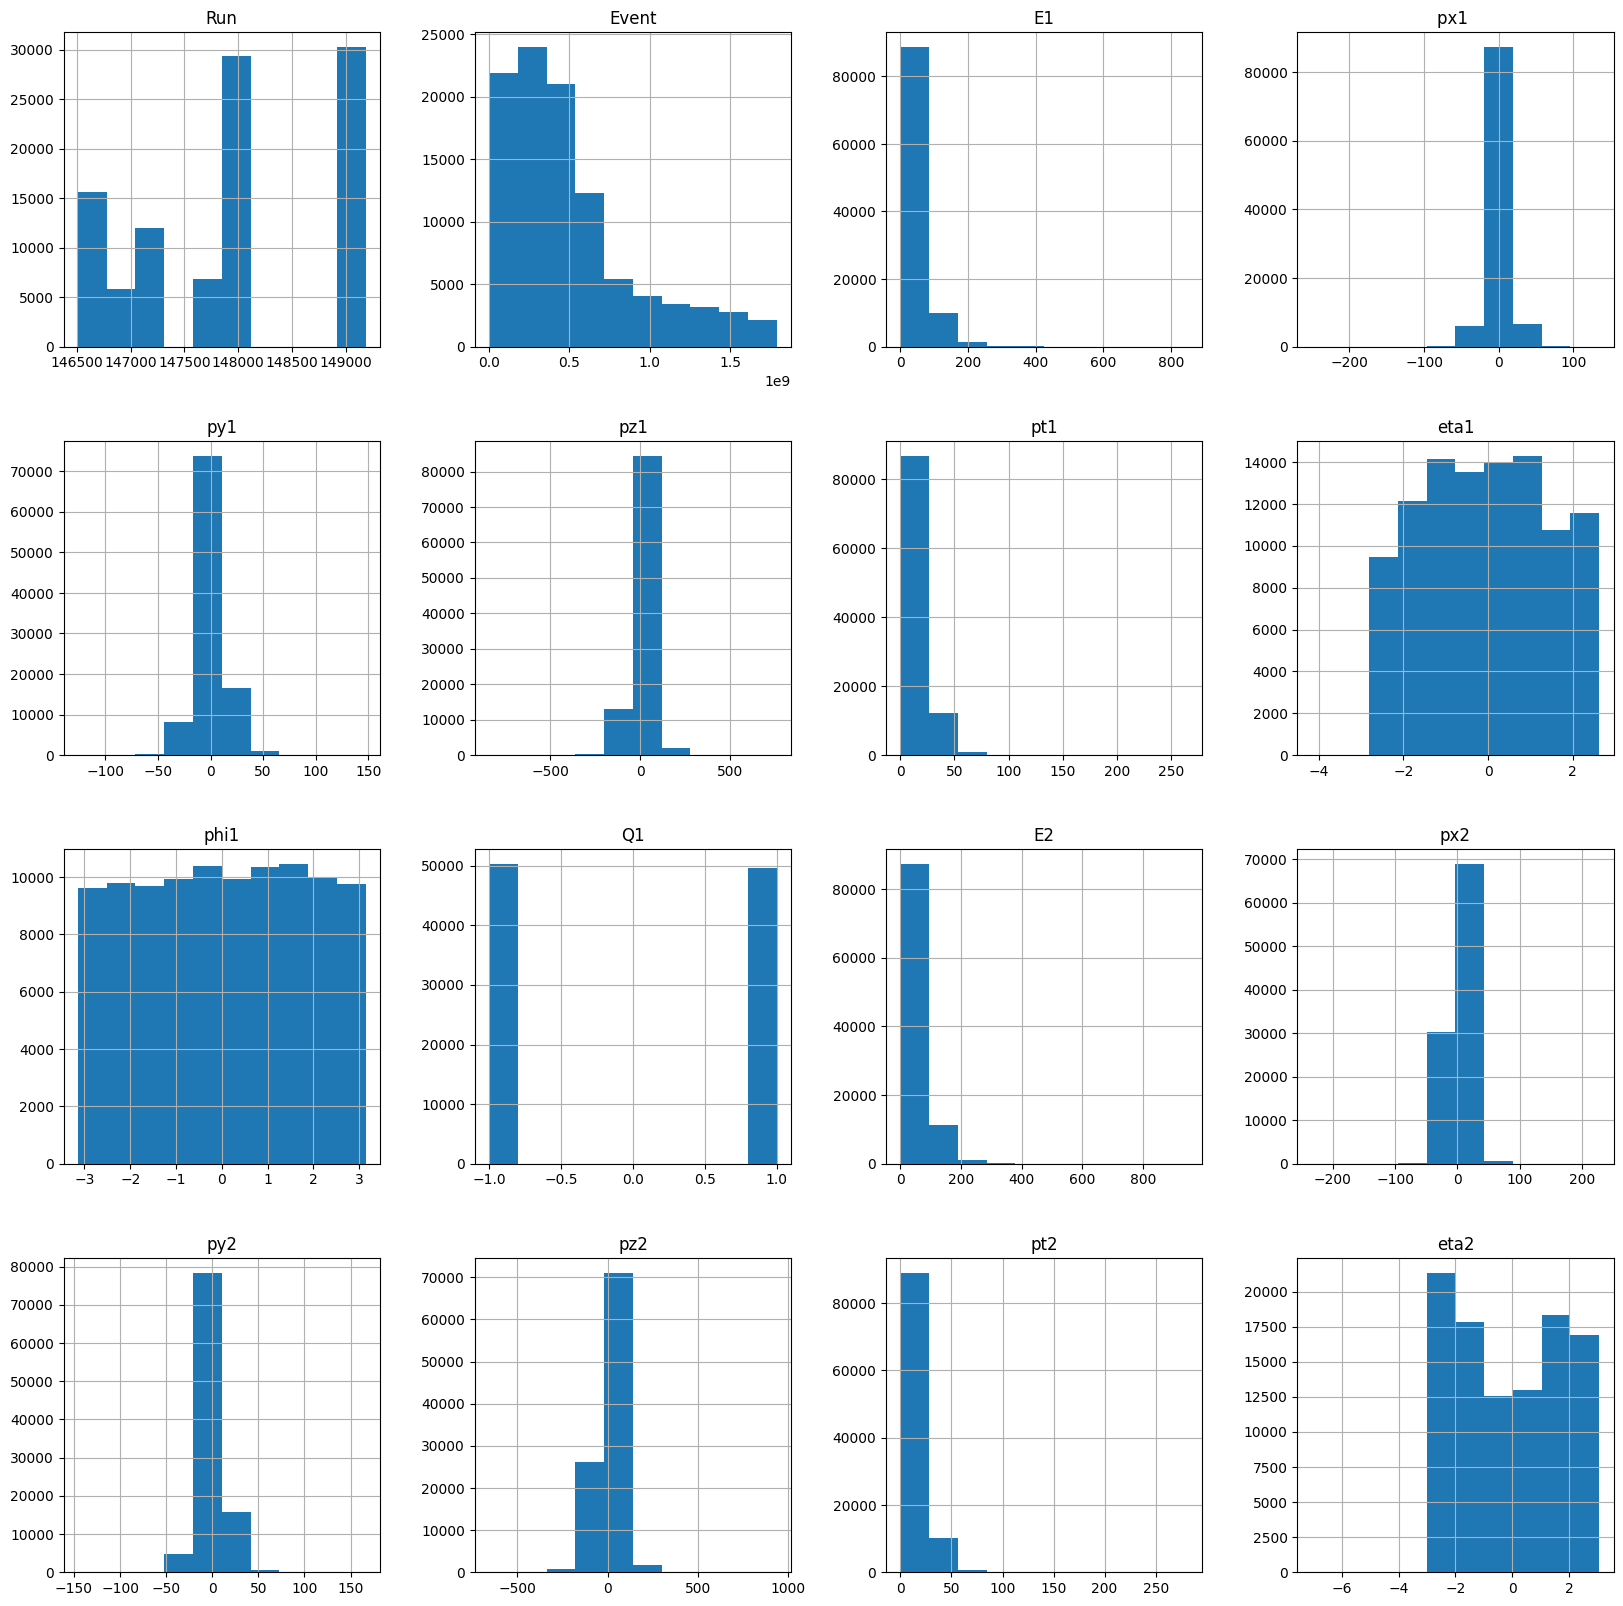

In [208]:
data.info()
data.dropna(inplace=True)
data.iloc[:,0:16].hist(figsize=(20,20))
plt.show()

Text(0.5, 1.0, 'Correlaciones')

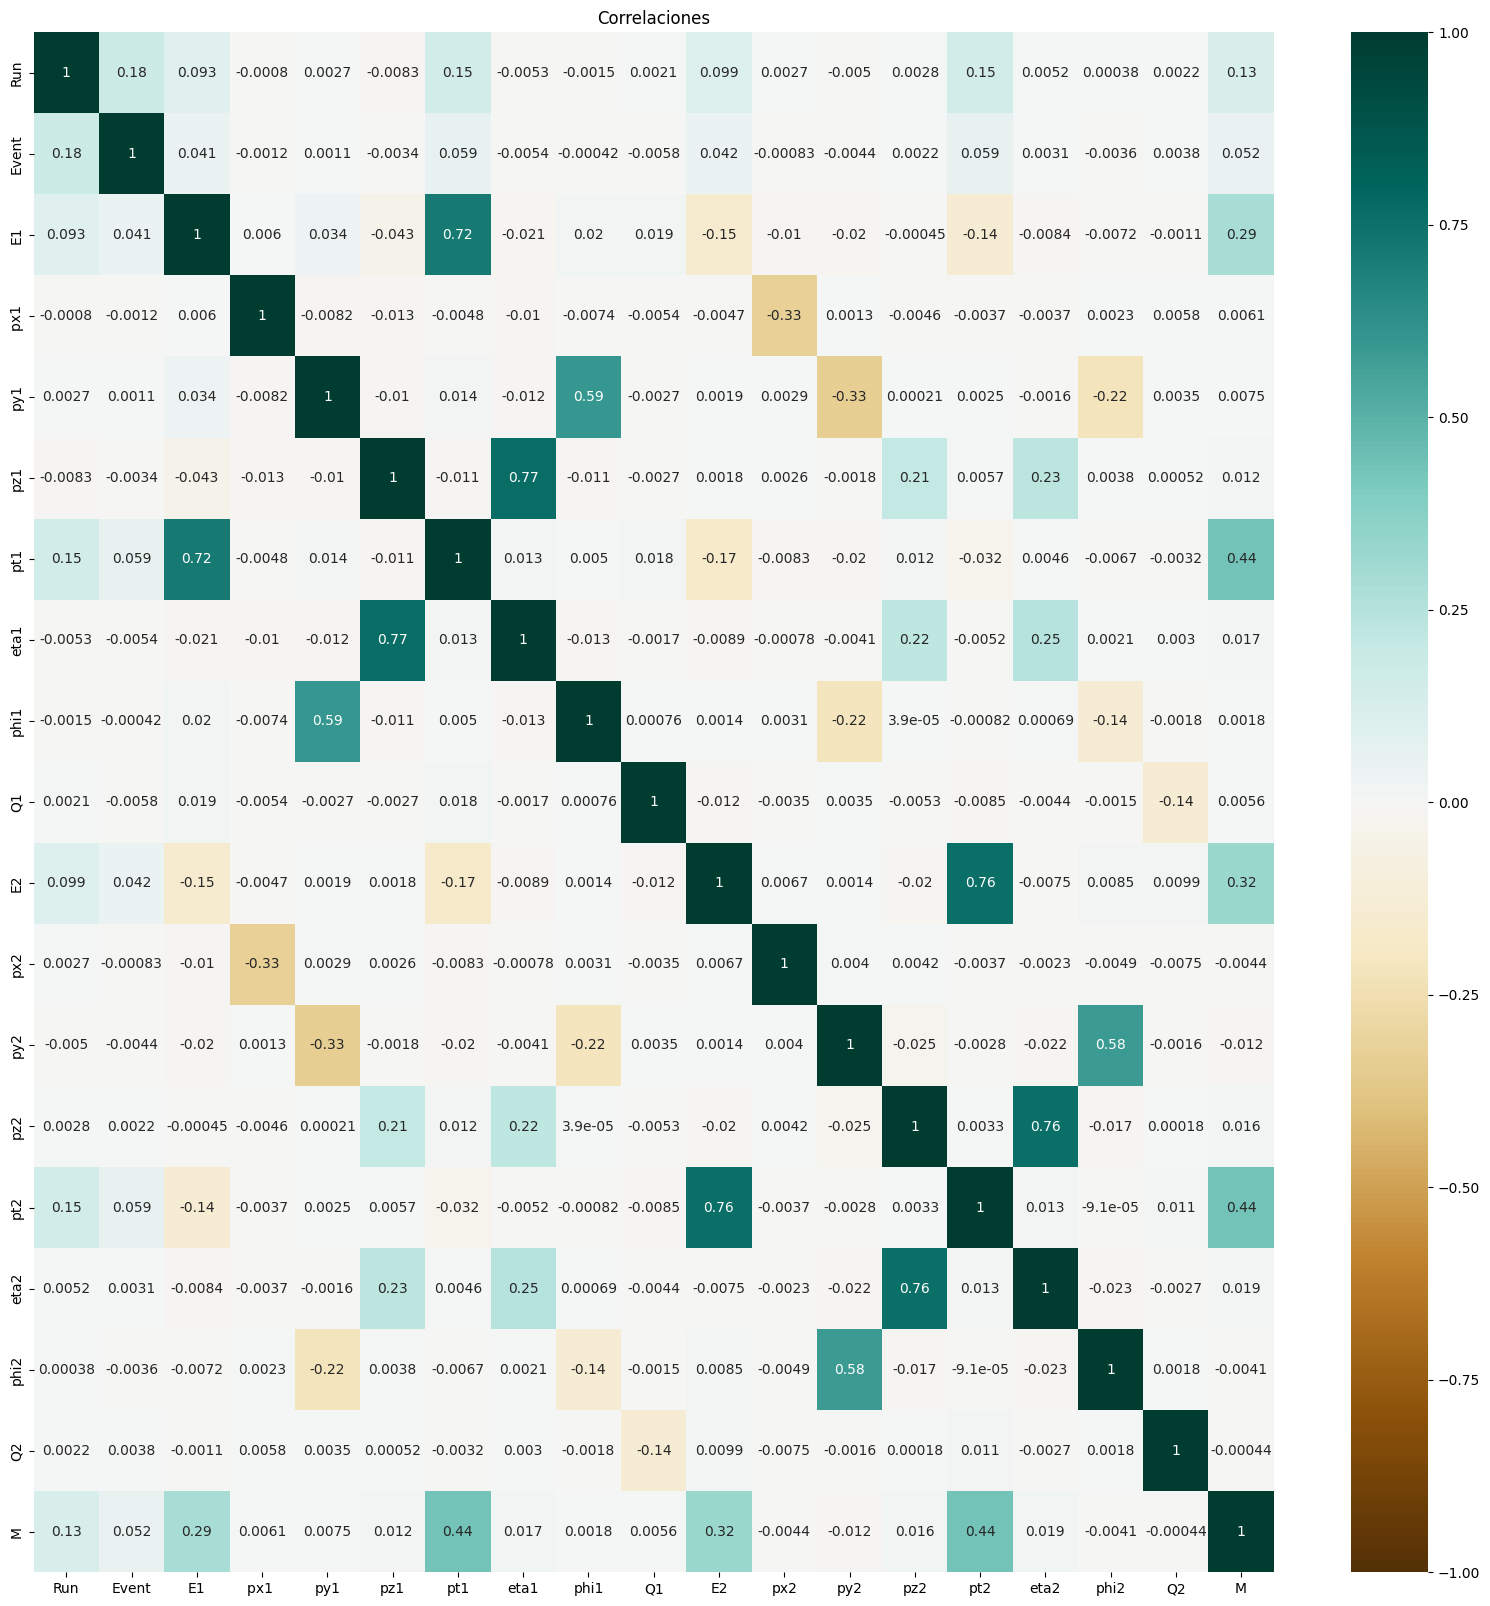

In [209]:
#Encontramos el mapa de correlaciones de nuestro dataframe
plt.figure(figsize=(20,20))
heatmap = sns.heatmap(data.corr(),vmin=-1,vmax=1,annot=True,cmap='BrBG')
heatmap.set_title('Correlaciones')
#Donde no encontramos en realidad alguna correlacion  lo suficientemente fuerte para ser eliminada

In [210]:
Y = data['M']
X = data.drop(columns=['M', 'Run', 'Event'])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.fit_transform(X_test)

Epoch 1/20
800/800 [==============================] - 25s 29ms/step - loss: 52.7170 - mse: 52.7170 - val_loss: 57.3954 - val_mse: 57.3954
Epoch 2/20
800/800 [==============================] - 29s 36ms/step - loss: 12.0147 - mse: 12.0147 - val_loss: 8.0496 - val_mse: 8.0496
Epoch 3/20
800/800 [==============================] - 17s 21ms/step - loss: 9.3645 - mse: 9.3645 - val_loss: 6.1809 - val_mse: 6.1809
Epoch 4/20
800/800 [==============================] - 21s 27ms/step - loss: 7.5338 - mse: 7.5338 - val_loss: 4.6487 - val_mse: 4.6487
Epoch 5/20
800/800 [==============================] - 16s 20ms/step - loss: 6.4084 - mse: 6.4084 - val_loss: 5.2541 - val_mse: 5.2541
Epoch 6/20
800/800 [==============================] - 18s 22ms/step - loss: 5.7807 - mse: 5.7807 - val_loss: 11.1466 - val_mse: 11.1466
Epoch 7/20
800/800 [==============================] - 17s 21ms/step - loss: 4.1076 - mse: 4.1076 - val_loss: 2.6120 - val_mse: 2.6120
Epoch 8/20
800/800 [==============================] - 

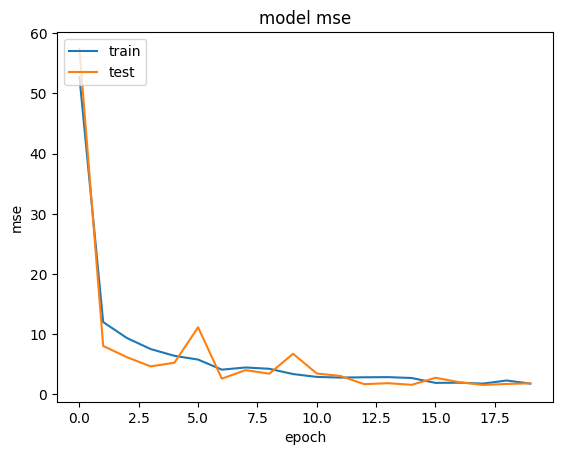

In [211]:
model = tf.keras.Sequential(
    [
  tf.keras.layers.Dense(512, activation = "relu", input_shape = (16,)),
  tf.keras.layers.Dense(256, activation = "relu"),
  tf.keras.layers.Dense(128, activation = "relu"),
  tf.keras.layers.Dense(64, activation = "relu"),
  tf.keras.layers.Dense(1),
    ]
)
model.compile(
  optimizer = tf.keras.optimizers.Adam(0.01),
  loss = 'mse',
  metrics = ['mse'],
)
history = model.fit(X_train,y_train, epochs=20, batch_size=100,validation_data=(X_test, y_test))
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])
plt.title('model mse')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [212]:
y_pred = model.predict(X_test)

625/625 [==============================] - 5s 8ms/step


In [213]:
mse(y_test,y_pred)


1.837244875680102

In [214]:
model.summary()

Model: "sequential_47"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_202 (Dense)           (None, 512)               8704      
                                                                 
 dense_203 (Dense)           (None, 256)               131328    
                                                                 
 dense_204 (Dense)           (None, 128)               32896     
                                                                 
 dense_205 (Dense)           (None, 64)                8256      
                                                                 
 dense_206 (Dense)           (None, 1)                 65        
                                                                 
Total params: 181,249
Trainable params: 181,249
Non-trainable params: 0
_________________________________________________________________
